# Лабораторная работа №8.


Разработка имитационной модели многоканальной вычислительной системы
с отказами.
Сопоставление различных архитектурных решений при увеличении входной нагрузки информационной системы

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import deque

import numpy as np
import pandas as pd
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Задание № 1.


Разработать компьютерную программу для имитационного моделирования многоканальной системы с отказами.

In [17]:
def exp_func(lmbd, p):
    return -1 / lmbd * np.log(p)

def generate_request_time_exp(lmbd, work_time):
    T_server = [0]
    while True:
        new_t = T_server[-1] + exp_func(lmbd, np.random.rand())
        if new_t > work_time:
            break
        T_server.append(new_t)
    T_server.pop(0)
    return np.asarray(T_server)

def generate_process_time_exp(lmbd, n):
    return exp_func(lmbd, np.random.rand(n))

def simulate(Ts, Tz, n):
    processed_signals = 0
    ends = [0] * n
    work_times = [0] * n
    rej_time = 0
    free_time = 0
    for i in range(len(Ts)):
        if np.min(ends) <= Ts[i]:
            if np.max(ends) <= Ts[i]:
                free_time += Ts[i] - np.max(ends)

            server_idx = ends.index(np.min(ends))
            work_times[server_idx] += Tz[i]
            ends[server_idx] = Ts[i] + Tz[i]
            processed_signals += 1

            if np.min(ends) > Ts[i]:
                rej_time += np.min(ends) - Ts[i]


    work_times = np.asarray(work_times)
    return processed_signals, work_times, free_time, rej_time


# Задание № 2.


Для разработанной программы провести расчеты для заданных входных параметров:

In [18]:
mu = 0.1
lmbd = 0.2
T = 1000
n = 2
T_req = generate_request_time_exp(lmbd, T)
T_processing = generate_process_time_exp(mu, len(T_req))

processed_signals, work_times, free_time, rej_time = simulate(T_req, T_processing, n)
print(f"Число обработанных сигналов: {processed_signals}")
print(f"Число отказов: {len(T_req) - processed_signals}")
print(f"Вероятность обработки заявки: {processed_signals / len(T_req)}")
print(f"Вероятность отказа в обслуживании: {1 - (processed_signals / len(T_req))}")
print(f"Время простоя каналов: {T - work_times}")
print(f"Вероятность загрузки каналов: {work_times / T}")

Число обработанных сигналов: 119
Число отказов: 67
Вероятность обработки заявки: 0.6397849462365591
Вероятность отказа в обслуживании: 0.3602150537634409
Время простоя каналов: [411.91130428 412.50666951]
Вероятность загрузки каналов: [0.5880887  0.58749333]


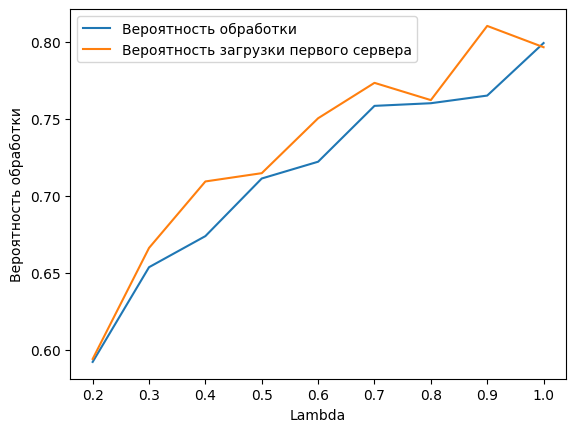

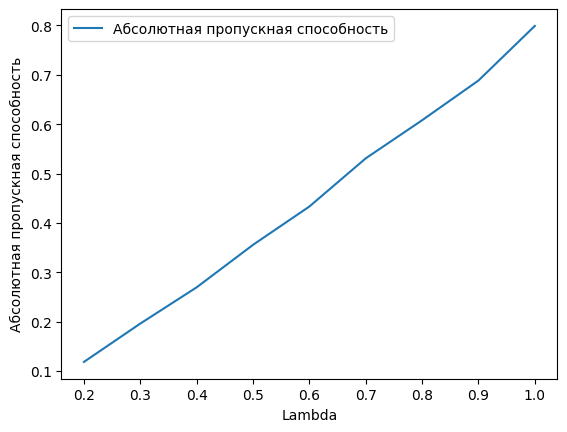

In [19]:
mu = 0.1
T = 1000

ns = np.arange(2, 11)
lmbds = ns * 0.1

all_ps = []
all_wts = []
for i in range(len(ns)):
    n = ns[i]
    lmbd = lmbds[i]

    c = 10
    cur_p = []
    cur_wt = []
    for _ in range(c):
        T_req = generate_request_time_exp(lmbd, T)
        T_processing = generate_process_time_exp(mu, len(T_req))

        processed_signals, work_times, free_time, rej_time = simulate(T_req, T_processing, n)

        cur_p.append(processed_signals / len(T_req))
        cur_wt.append(work_times[0] / T)
    all_ps.append(np.mean(cur_p))
    all_wts.append(np.mean(cur_wt))

plt.plot(lmbds, all_ps, label="Вероятность обработки")
plt.plot(lmbds, all_wts, label="Вероятность загрузки первого сервера")
plt.xlabel("Lambda")
plt.ylabel("Вероятность обработки")
plt.legend()
plt.show()

table_rows = [f"n = {n}, lmbd = {n * 0.1:.3}" for n in ns]
df = pd.DataFrame({"Qn": all_ps, "Tn": all_wts}, index=table_rows)
df

all_A = []
for i in range(len(all_ps)):
    all_A.append(all_ps[i] * lmbds[i])

plt.plot(lmbds, all_A, label="Абсолютная пропускная способность")
# plt.plot(lmbds, all_wts, label="Вероятность загрузки первого сервера")
plt.xlabel("Lambda")
plt.ylabel("Абсолютная пропускная способность")
plt.legend()
plt.show()

In [ ]:
from math import factorial

# Параметры для случая n = 10 каналов
mu_analytics = 0.1
n_analytics = 10
lmbd_analytics = 1

rho = lmbd_analytics / mu_analytics

denominator = sum((rho ** k) / factorial(k) for k in range(n_analytics + 1))
P_0 = 1 / denominator

P_f = rho ** n_analytics / factorial(n_analytics) * P_0

# Относительная пропускная способность
Q_analytics = 1 - P_f

# Абсолютная пропускная способность
A_analytics = Q_analytics * lmbd_analytics

# Среднее число занятых каналов
k_anylytics = Q_analytics * rho
# Вероятность загрузки одного сервера = среднее число занятых каналов / n
T_analytics = k_anylytics / n_analytics


print(f"Относительная пропускная способность: {Q_analytics:.2f}")
print(f"Абсолютная пропускная способность: {A_analytics:.2f}")
print(f"Среднее число занятых каналов: {k_anylytics:.2f}")
print(f"Вероятность загрузки одного сервера: {T_analytics:.6f}")

Относительная пропускная способность: 0.79
Абсолютная пропускная способность: 0.79
Среднее число занятых каналов: 7.85
Вероятность загрузки одного сервера: 0.785418


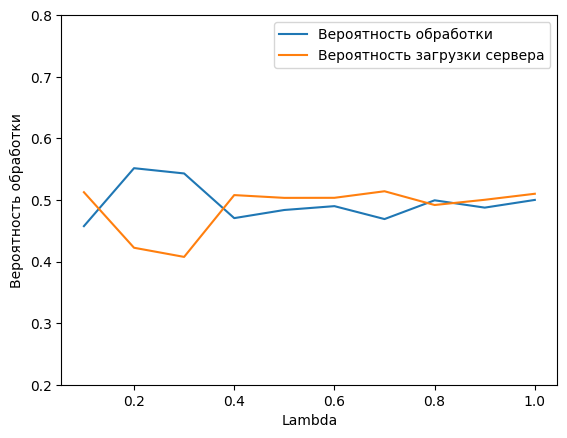

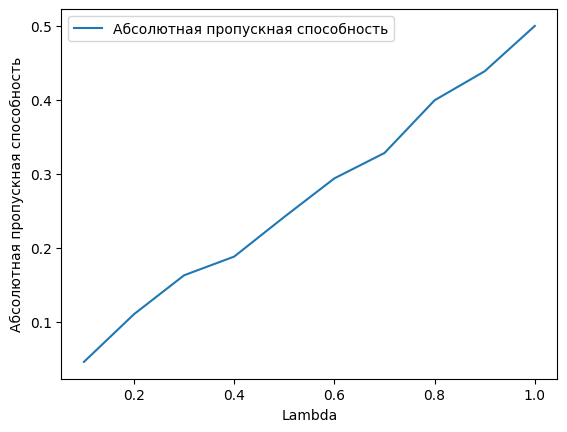

In [20]:
n = 1
T = 1000

mus = np.arange(1, 11) * 0.1
lmbds = np.arange(1, 11) * 0.1

all_ps = []
all_wts = []
for i in range(len(mus)):
    mu = mus[i]
    lmbd = lmbds[i]

    c = 1
    cur_p = []
    cur_wt = []
    for _ in range(c):
        T_req = generate_request_time_exp(lmbd, T)
        T_processing = generate_process_time_exp(mu, len(T_req))

        processed_signals, work_times, free_time, rej_time = simulate(T_req, T_processing, n)

        cur_p.append(processed_signals / len(T_req))
        cur_wt.append(work_times[0] / T)
    all_ps.append(np.mean(cur_p))
    all_wts.append(np.mean(cur_wt))

plt.plot(lmbds, all_ps, label="Вероятность обработки")
plt.plot(lmbds, all_wts, label="Вероятность загрузки сервера")
plt.xlabel("Lambda")
plt.ylabel("Вероятность обработки")
plt.legend()
plt.ylim(0.2, 0.8)
plt.show()

table_rows = [f"mu = {mu}, lmbd = {mu}" for mu in mus]
df = pd.DataFrame({"Qn": all_ps, "Tn": all_wts}, index=table_rows)
df

all_A = []
for i in range(len(all_ps)):
    all_A.append(all_ps[i] * lmbds[i])

plt.plot(lmbds, all_A, label="Абсолютная пропускная способность")
# plt.plot(lmbds, all_wts, label="Вероятность загрузки первого сервера")
plt.xlabel("Lambda")
plt.ylabel("Абсолютная пропускная способность")
plt.legend()
plt.show()

In [25]:
from math import factorial

# Параметры для случая n = 1 канал, mu = 1, lambda = 1
mu_analytics = 1.0
n_analytics = 1
lmbd_analytics = 1.0

rho = lmbd_analytics / mu_analytics

P_0 = 1 / (1 + rho)

P_f = rho  * P_0

# Относительная пропускная способность
Q_analytics = 1 / (1 + rho)

# Абсолютная пропускная способность
A_analytics = Q_analytics * lmbd_analytics

# Коэффициент загрузки каналов
k_anylytics = A_analytics / mu_analytics

print(f"Относительная пропускная способность: {Q_analytics:.2f}")
print(f"Абсолютная пропускная способность: {A_analytics:.2f}")
print(f"Коэффициент загрузки канала: {k_anylytics:.2f}")


Относительная пропускная способность: 0.50
Абсолютная пропускная способность: 0.50
Коэффициент загрузки канала: 0.50
